In [ ]:
# House Price Prediction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)

In [2]:
# Regression: House Price Prediction
# Data prep (condensed from Day 2)

np.random.seed(7)
n = 5000

median_income = np.round(np.random.gamma(shape=3.0, scale=1.5, size=n), 2)
house_age = np.random.randint(1, 55, size=n)
avg_rooms = np.round(np.random.normal(6, 1.5, size=n).clip(2, 15), 2)
avg_bedrooms = np.round(avg_rooms * np.random.uniform(0.15, 0.3, size=n), 2)
population = np.random.randint(200, 5000, size=n)
avg_occup = np.round(np.random.normal(3, 0.8, size=n).clip(1, 8), 2)
latitude = np.round(np.random.uniform(33.5, 41.5, size=n), 3)
longitude = np.round(np.random.uniform(-124, -114, size=n), 3)

price_target = (
    0.55 * median_income + 0.02 * avg_rooms - 0.01 * house_age
    - 0.3 * avg_occup + np.random.normal(0, 1.2, size=n)
).clip(0.2, 5.0)

df = pd.DataFrame({
    "MedInc": median_income, "HouseAge": house_age, "AveRooms": avg_rooms,
    "AveBedrms": avg_bedrooms, "Population": population, "AveOccup": avg_occup,
    "Latitude": latitude, "Longitude": longitude,
    "PriceTarget": np.round(price_target, 3),
})

def lat_to_region(lat):
    if lat > 38: return "NORTH"
    elif lat > 35: return "CENTRAL"
    else: return "SOUTH"
df["region"] = df["Latitude"].apply(lat_to_region)

# inject missing values + outliers, then clean (Day 2 + Day 3 steps)
for col in ["AveBedrms", "Population"]:
    mask = np.random.rand(len(df)) < 0.03
    df.loc[mask, col] = np.nan
outlier_idx = np.random.choice(df.index, size=25, replace=False)
df.loc[outlier_idx, "AveRooms"] = np.random.uniform(20, 40, size=25)

df["AveBedrms"] = df["AveBedrms"].fillna(df["AveBedrms"].median())
df["Population"] = df["Population"].fillna(df["Population"].median())
df["AveRooms"] = df["AveRooms"].clip(upper=15)
df = pd.get_dummies(df, columns=["region"], drop_first=True)

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (5000, 11)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PriceTarget,region_NORTH,region_SOUTH
0,2.96,23,6.38,1.48,1580.0,1.83,41.109,-116.220,0.823,True,False
1,2.36,2,6.97,1.18,3910.0,5.38,37.375,-114.262,0.200,False,False
2,4.01,16,5.06,1.31,1068.0,3.45,34.645,-121.183,0.200,False,True
3,7.05,20,9.35,1.99,2399.0,2.79,41.177,-115.147,4.855,True,False
4,5.66,51,8.99,2.04,2580.0,1.40,34.742,-114.602,2.231,False,True


In [3]:
# Train/test split + scaling + training (Day 3)

X = df.drop(columns=["PriceTarget"])
y = df["PriceTarget"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_pred_test = reg_model.predict(X_test_scaled)
y_pred_train = reg_model.predict(X_train_scaled)

coef_df = pd.DataFrame({"feature": X.columns, "coefficient": reg_model.coef_}).sort_values(
    "coefficient", key=abs, ascending=False
)
print("Top features by impact:")
coef_df.head()

Top features by impact:


,feature,coefficient
0,MedInc,1.017095
5,AveOccup,-0.179405
1,HouseAge,-0.096905
2,AveRooms,0.038177
9,region_SOUTH,-0.030722


In [4]:
# Evaluation (Day 4)

metrics = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "R2"],
    "train": [
        mean_absolute_error(y_train, y_pred_train),
        mean_squared_error(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        r2_score(y_train, y_pred_train),
    ],
    "test": [
        mean_absolute_error(y_test, y_pred_test),
        mean_squared_error(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        r2_score(y_test, y_pred_test),
    ],
})
metrics

,metric,train,test
0,MAE,0.738079,0.735262
1,MSE,0.873732,0.874695
2,RMSE,0.934736,0.935251
3,R2,0.553538,0.568434


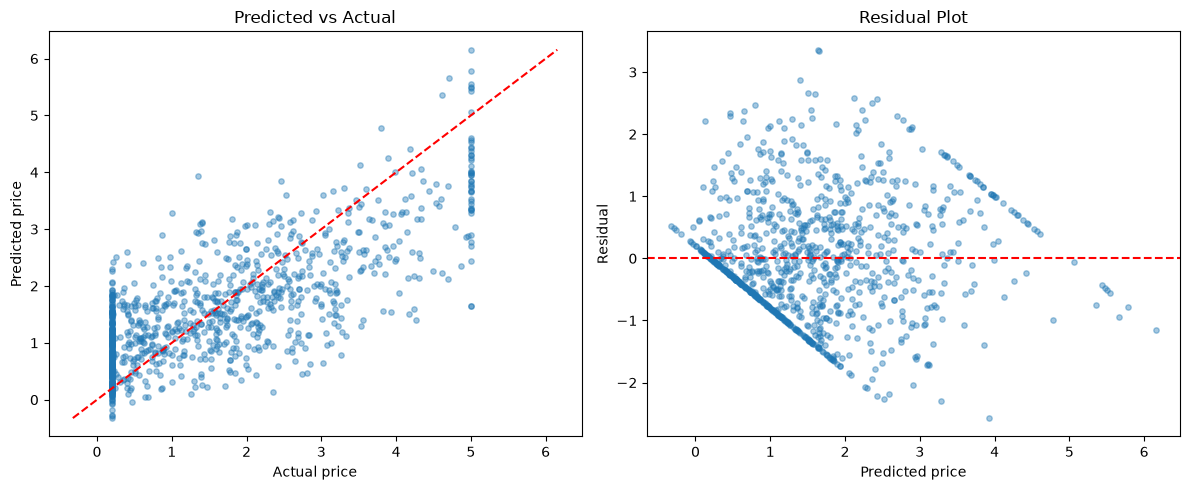

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("Actual price"); axes[0].set_ylabel("Predicted price")
axes[0].set_title("Predicted vs Actual")

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted price"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

In [6]:
# Classification: Logistic Regression (Day 5)

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
cdf = data.frame.copy()

Xc = cdf.drop(columns=["target"])
yc = cdf["target"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

c_scaler = StandardScaler()
Xc_train_scaled = c_scaler.fit_transform(Xc_train)
Xc_test_scaled = c_scaler.transform(Xc_test)

clf = LogisticRegression()
clf.fit(Xc_train_scaled, yc_train)
yc_pred = clf.predict(Xc_test_scaled)

acc = accuracy_score(yc_test, yc_pred)
print(f"Accuracy: {acc:.4f}")
print()
print(classification_report(yc_test, yc_pred, target_names=data.target_names))

Accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



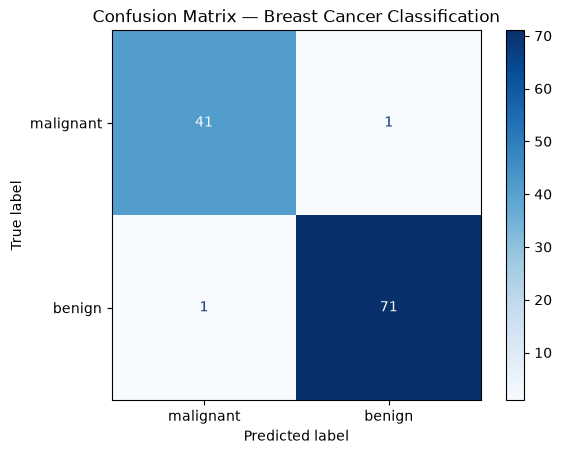

In [7]:
cm = confusion_matrix(yc_test, yc_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names).plot(cmap="Blues")
plt.title("Confusion Matrix — Breast Cancer Classification")
plt.show()